# Clustering Results Visualization

This notebook loads the clustering results (K-Means / GMM) and creates interpretable visualizations:

1. **PCA Explanation** - Understanding the 2D scatter plot
2. **Interactive Scatter** - City names instead of geo codes
3. **Profile Heatmap** - What defines each cluster
4. **Radar Charts** - Key feature comparison
5. **Geographic Map** - Spatial distribution of clusters

## 1. Setup and Data Loading

In [1]:
import sys
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA

from src.clustering import db as dbmod
from src.clustering.extract import fetch_city_entities

# Configuration
ALGORITHM = "gmm"  # Change to "kmeans" if you prefer
RUN_DIR = PROJECT_ROOT / "output" / "clustering" / "custom_run_20260113_202817"

print(f"Loading results from: {RUN_DIR / ALGORITHM}")

Loading results from: /Users/felixwegener/freelancing/data-analytics-project/output/clustering/custom_run_20260113_202817/gmm


In [2]:
# Load clustering results
labels_df = pd.read_csv(RUN_DIR / ALGORITHM / "labels.csv")
profiles_df = pd.read_csv(RUN_DIR / ALGORITHM / "profiles.csv")
X_scaled_df = pd.read_csv(RUN_DIR / "X_scaled.csv")

# Load city names from database
db_path = dbmod.default_data_full_db_path()
con = dbmod.connect(db_path)
city_entities = fetch_city_entities(con)
con.close()

# Join city names onto labels
labels_df = labels_df.merge(
    city_entities[["geo_code", "geo_name", "country_code"]], 
    on="geo_code", 
    how="left"
)

# Create a display name (city name + country)
labels_df["display_name"] = labels_df["geo_name"].fillna(labels_df["geo_code"])

print(f"Loaded {len(labels_df)} cities across {labels_df['cluster_id'].nunique()} clusters")
labels_df.head(10)

Loaded 66 cities across 4 clusters


,geo_code,cluster_id,membership_prob,geo_name,country_code,display_name
0,BE001C,0,0.992562,Bruxelles/Brussel (greater city),BE,Bruxelles/Brussel (greater city)
1,BE002C,0,1.000000,Antwerpen (greater city),BE,Antwerpen (greater city)
2,BG001C,3,1.000000,Sofia,BG,Sofia
3,CH002C,0,1.000000,Zurich (greater city),CH,Zurich (greater city)
4,CZ001C,0,0.999841,Praha,CZ,Praha
5,DE001C,1,1.000000,Berlin,DE,Berlin
6,DE002C,2,0.999999,Hamburg,DE,Hamburg
7,DE003C,2,1.000000,München,DE,München
8,DE004C,0,0.999985,Köln,DE,Köln
9,DE005C,0,0.941279,Frankfurt am Main,DE,Frankfurt am Main


In [3]:
# Feature name mapping for human-readable labels
FEATURE_LABELS = {
    "URB_CPOP1_DE1001V": "City Population",
    "URB_CEDUC_TE1026V": "Higher Ed Students",
    "URB_CLMA_EC1010V": "Employed (20-64)",
    "URB_CLMA_EC1177V": "Unemployed Total",
    "URB_CPOPCB_DE2009V": "Foreign Population",
    "URB_CTOUR_CR2001V": "Tourist Nights",
    "URB_CTRAN_TT1057I": "Cars per 1000",
    "WHO_PM25": "PM2.5 (μg/m³)",
    "WHO_PM10": "PM10 (μg/m³)",
    "WHO_NO2": "NO2 (μg/m³)",
    "COUNTRY_SDG_11_60": "Recycling Rate %",
    "COUNTRY_SDG_17_60_VHCN_FX_TOTAL": "Internet VHCN %",
    "COUNTRY_HLTH_RS_BDS1_HBEDT_TOTAL": "Hospital Beds/100k",
    "COUNTRY_TRNG_LFSE_01_T_Y25-74": "Adult Education %",
    "COUNTRY_ISOC_CIEGI_AC_I_IUGOV12_IND_TOTAL": "E-Gov Usage %",    
}

def clean_feature_name(name: str) -> str:
    """Convert technical feature name to human-readable label."""
    return FEATURE_LABELS.get(name, name)

# Show cluster distribution
cluster_counts = labels_df.groupby("cluster_id")["display_name"].agg(["count", lambda x: ", ".join(x[:5]) + ("..." if len(x) > 5 else "")])
cluster_counts.columns = ["Count", "Sample Cities"]
cluster_counts

,Count,Sample Cities
cluster_id,,
0,43,"Bruxelles/Brussel (greater city), Antwerpen (g..."
1,6,"Berlin, Madrid (greater city), Barcelona (grea..."
2,6,"Hamburg, München, Budapest (greater city), 's-..."
3,11,"Sofia, Zagreb, Torino, Palermo, Genova..."


## 2. Understanding PCA (Principal Component Analysis)

### What is PCA?

PCA is a dimensionality reduction technique that transforms high-dimensional data into a lower-dimensional representation while preserving as much variance as possible.

**In our context:**
- We have **22 features** per city (population, air quality, employment, etc.)
- PCA projects this 22-dimensional space onto **2 dimensions** for visualization
- **PC1 (x-axis)**: The direction that captures the **most variance** in the data
- **PC2 (y-axis)**: Perpendicular to PC1, captures the **second most variance**

### Interpreting the Plot
- Cities that are **close together** are similar across all 22 features
- Cities that are **far apart** differ significantly
- The **distance along PC1** matters more than PC2 (it explains more variance)

### What do PC1 and PC2 actually represent?
The loadings below show which original features contribute most to each principal component:

In [4]:
# Perform PCA and analyze loadings
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_df.values)

# Create loadings dataframe
feature_names = X_scaled_df.columns.tolist()
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=feature_names
)

# Add human-readable names
loadings["Feature"] = loadings.index.map(clean_feature_name)
loadings["PC1_abs"] = loadings["PC1"].abs()
loadings["PC2_abs"] = loadings["PC2"].abs()

print(f"Variance explained: PC1 = {pca.explained_variance_ratio_[0]:.1%}, PC2 = {pca.explained_variance_ratio_[1]:.1%}")
print(f"Total variance explained by 2D projection: {pca.explained_variance_ratio_.sum():.1%}")
print()

# Show top contributors to each PC
print("=" * 60)
print("TOP FEATURES DRIVING PC1 (x-axis):")
print("=" * 60)
top_pc1 = loadings.nlargest(5, "PC1_abs")[["Feature", "PC1"]]
for _, row in top_pc1.iterrows():
    direction = "→ RIGHT" if row["PC1"] > 0 else "← LEFT"
    print(f"  {row['Feature']:30s} {row['PC1']:+.3f} {direction}")

print()
print("=" * 60)
print("TOP FEATURES DRIVING PC2 (y-axis):")
print("=" * 60)
top_pc2 = loadings.nlargest(5, "PC2_abs")[["Feature", "PC2"]]
for _, row in top_pc2.iterrows():
    direction = "↑ UP" if row["PC2"] > 0 else "↓ DOWN"
    print(f"  {row['Feature']:30s} {row['PC2']:+.3f} {direction}")

Variance explained: PC1 = 47.2%, PC2 = 22.5%
Total variance explained by 2D projection: 69.7%

TOP FEATURES DRIVING PC1 (x-axis):
  Tourist Nights                 +0.648 → RIGHT
  Unemployed Total               +0.420 → RIGHT
  Employed (20-64)               +0.390 → RIGHT
  City Population                +0.345 → RIGHT
  Foreign Population             +0.262 → RIGHT

TOP FEATURES DRIVING PC2 (y-axis):
  E-Gov Usage %                  +0.678 ↑ UP
  PM2.5 (μg/m³)                  -0.429 ↓ DOWN
  Cars per 1000                  -0.334 ↓ DOWN
  PM10 (μg/m³)                   -0.293 ↓ DOWN
  Adult Education %              +0.289 ↑ UP


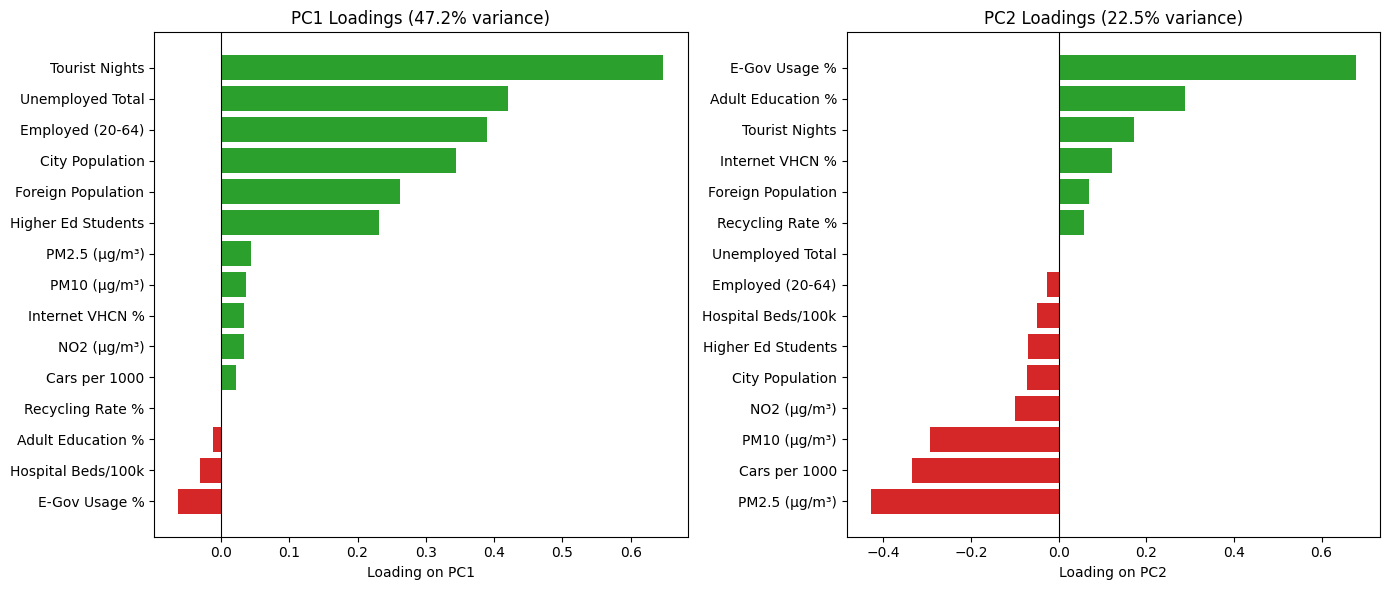

In [5]:
# Visualize PCA loadings as a bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PC1 loadings
ax1 = axes[0]
sorted_pc1 = loadings.sort_values("PC1")
colors = ["#d62728" if v < 0 else "#2ca02c" for v in sorted_pc1["PC1"]]
ax1.barh(sorted_pc1["Feature"], sorted_pc1["PC1"], color=colors)
ax1.axvline(x=0, color="black", linewidth=0.8)
ax1.set_xlabel("Loading on PC1")
ax1.set_title(f"PC1 Loadings ({pca.explained_variance_ratio_[0]:.1%} variance)")

# PC2 loadings
ax2 = axes[1]
sorted_pc2 = loadings.sort_values("PC2")
colors = ["#d62728" if v < 0 else "#2ca02c" for v in sorted_pc2["PC2"]]
ax2.barh(sorted_pc2["Feature"], sorted_pc2["PC2"], color=colors)
ax2.axvline(x=0, color="black", linewidth=0.8)
ax2.set_xlabel("Loading on PC2")
ax2.set_title(f"PC2 Loadings ({pca.explained_variance_ratio_[1]:.1%} variance)")

plt.tight_layout()
plt.savefig(RUN_DIR / "pca_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Interactive PCA Scatter Plot

This plot shows the same 2D projection but with **city names** and **interactive hover** for exploration.

In [6]:
# Create PCA scatter dataframe with city info
pca_df = pd.DataFrame({
    "geo_code": labels_df["geo_code"],
    "city_name": labels_df["display_name"],
    "country": labels_df["country_code"],
    "cluster_id": labels_df["cluster_id"],
    "membership_prob": labels_df["membership_prob"],
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
})

# Create cluster name mapping for better legend
cluster_names = {
    i: f"Cluster {i} (n={len(pca_df[pca_df.cluster_id == i])})" 
    for i in sorted(pca_df["cluster_id"].unique())
}
pca_df["cluster_name"] = pca_df["cluster_id"].map(cluster_names)

# Interactive scatter with Plotly
fig = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    color="cluster_name",
    text="city_name",
    hover_data=["geo_code", "country", "membership_prob"],
    title=f"City Clustering ({ALGORITHM.upper()}) - PCA Projection",
    labels={"PC1": f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)",
            "PC2": f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)"},
    color_discrete_sequence=px.colors.qualitative.Set1,
)

# Adjust text positioning
fig.update_traces(
    textposition="top center",
    textfont_size=9,
    marker=dict(size=12, line=dict(width=1, color="white"))
)

fig.update_layout(
    width=1000,
    height=700,
    legend_title="Cluster",
    font=dict(size=12),
)

fig.show()

# Save as HTML for sharing
fig.write_html(RUN_DIR / f"interactive_scatter_{ALGORITHM}.html")
print(f"Saved interactive plot to: {RUN_DIR / f'interactive_scatter_{ALGORITHM}.html'}")

Saved interactive plot to: /Users/felixwegener/freelancing/data-analytics-project/output/clustering/custom_run_20260113_202817/interactive_scatter_gmm.html


## 4. Cluster Profile Heatmap

This heatmap shows the **z-score** of each feature for each cluster:
- **Red cells**: Cluster is notably **above average** on this feature
- **Blue cells**: Cluster is notably **below average** on this feature
- Values near 0 (white): Cluster is average on this feature

This is the most useful view for **interpreting what each cluster represents**.

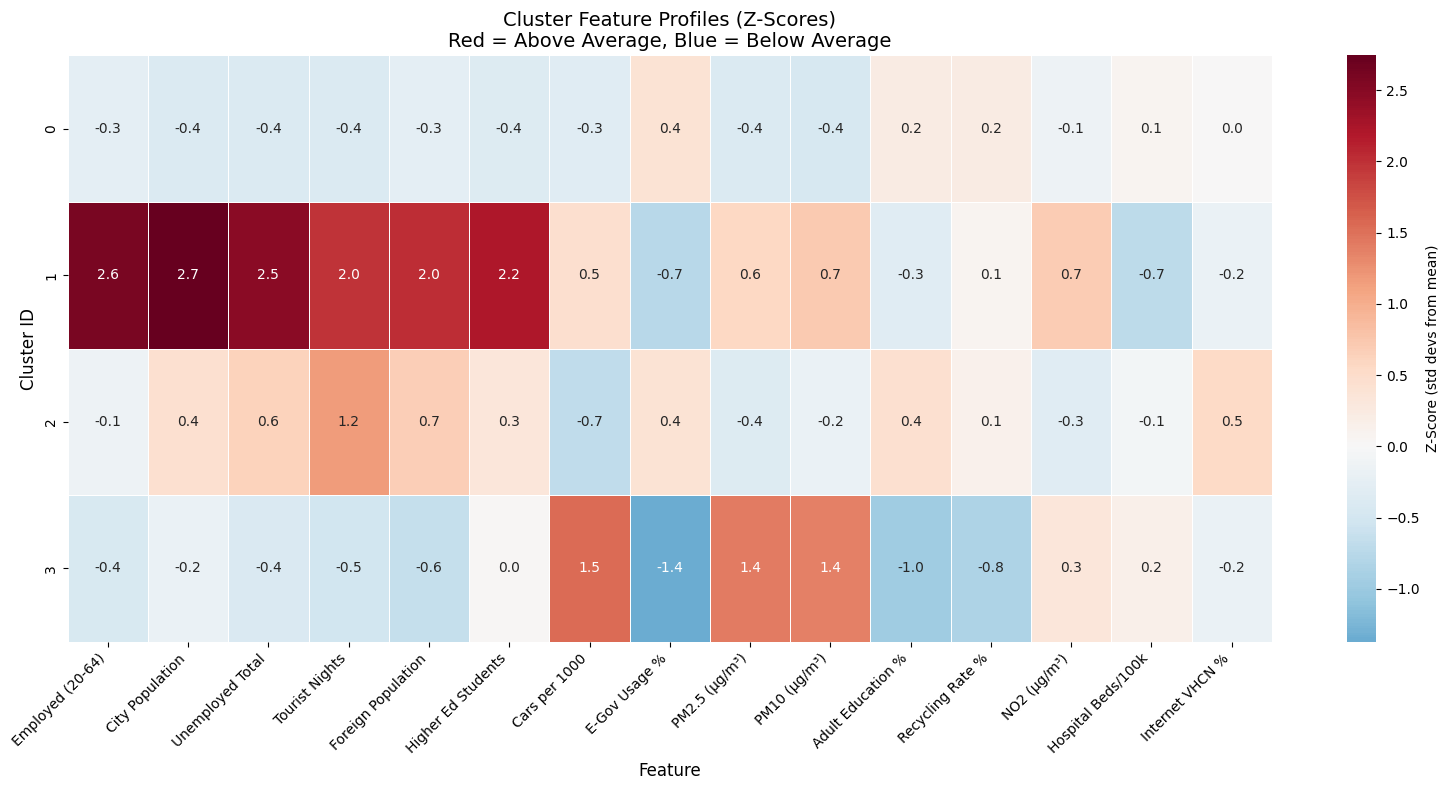

Saved heatmap to: /Users/felixwegener/freelancing/data-analytics-project/output/clustering/custom_run_20260113_202817/cluster_heatmap_gmm.png


In [7]:
# Pivot profiles to heatmap format
heatmap_df = profiles_df.pivot(
    index="cluster_id", 
    columns="feature_name", 
    values="z_mean"
)

# Clean up column names
heatmap_df.columns = [clean_feature_name(c) for c in heatmap_df.columns]

# Sort columns by absolute variance across clusters (most differentiating first)
col_importance = heatmap_df.std(axis=0).sort_values(ascending=False)
heatmap_df = heatmap_df[col_importance.index]

# Create heatmap
fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(
    heatmap_df,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={"label": "Z-Score (std devs from mean)"},
    ax=ax
)

ax.set_title("Cluster Feature Profiles (Z-Scores)\nRed = Above Average, Blue = Below Average", fontsize=14)
ax.set_xlabel("Feature", fontsize=12)
ax.set_ylabel("Cluster ID", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(RUN_DIR / f"cluster_heatmap_{ALGORITHM}.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved heatmap to: {RUN_DIR / f'cluster_heatmap_{ALGORITHM}.png'}")

In [8]:
# Auto-generate cluster interpretations
print("=" * 70)
print("CLUSTER INTERPRETATIONS (based on z-scores)")
print("=" * 70)

for cluster_id in sorted(heatmap_df.index):
    row = heatmap_df.loc[cluster_id]
    
    # Get high and low features (|z| > 0.5)
    high_features = row[row > 0.5].sort_values(ascending=False)
    low_features = row[row < -0.5].sort_values(ascending=True)
    
    # Get cities in this cluster
    cities_in_cluster = labels_df[labels_df["cluster_id"] == cluster_id]["display_name"].tolist()
    
    print(f"\n{'─' * 70}")
    print(f"CLUSTER {cluster_id} ({len(cities_in_cluster)} cities)")
    print(f"Cities: {', '.join(cities_in_cluster[:6])}{'...' if len(cities_in_cluster) > 6 else ''}")
    print(f"{'─' * 70}")
    
    if len(high_features) > 0:
        print("  ▲ HIGH:")
        for feat, z in high_features.head(4).items():
            print(f"    • {feat}: z={z:+.1f}")
    
    if len(low_features) > 0:
        print("  ▼ LOW:")
        for feat, z in low_features.head(4).items():
            print(f"    • {feat}: z={z:+.1f}")

CLUSTER INTERPRETATIONS (based on z-scores)

──────────────────────────────────────────────────────────────────────
CLUSTER 0 (43 cities)
Cities: Bruxelles/Brussel (greater city), Antwerpen (greater city), Zurich (greater city), Praha, Köln, Frankfurt am Main...
──────────────────────────────────────────────────────────────────────

──────────────────────────────────────────────────────────────────────
CLUSTER 1 (6 cities)
Cities: Berlin, Madrid (greater city), Barcelona (greater city), Roma, Milano (greater city), Napoli (greater city)
──────────────────────────────────────────────────────────────────────
  ▲ HIGH:
    • City Population: z=+2.7
    • Employed (20-64): z=+2.6
    • Unemployed Total: z=+2.5
    • Higher Ed Students: z=+2.2
  ▼ LOW:
    • E-Gov Usage %: z=-0.7
    • Hospital Beds/100k: z=-0.7

──────────────────────────────────────────────────────────────────────
CLUSTER 2 (6 cities)
Cities: Hamburg, München, Budapest (greater city), 's-Gravenhage (greater city), Lisboa 

## 5. Feature Importance (Why these clusters?)

Clustering is unsupervised, so we don’t get “feature importance” directly like in supervised ML. But we *can* quantify which features best explain the separation we see:

- **Separation scores (direct)**: Which features vary most between clusters (ANOVA / z-score spread)
- **Supervised proxy (explain labels)**: Train a lightweight classifier to predict `cluster_id` from the scaled features and compute **permutation importance**

These are interpretability tools to answer: **“What makes Cluster A different from Cluster B?”**

In [9]:
from sklearn.feature_selection import f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# Prepare X/y for explainability
X = X_scaled_df.values
y = labels_df["cluster_id"].astype(int).values

# --- 1) Direct separation: ANOVA F-score ---
# Higher F => stronger separation between clusters on that feature
f_vals, p_vals = f_classif(X, y)
fi_anova = (
    pd.DataFrame({
        "feature": X_scaled_df.columns,
        "feature_label": [clean_feature_name(c) for c in X_scaled_df.columns],
        "f_score": f_vals,
        "p_value": p_vals,
    })
    .sort_values("f_score", ascending=False)
    .reset_index(drop=True)
)

# --- 2) Direct separation: z-score spread (already computed as col_importance) ---
# col_importance is std(z_mean across clusters) from heatmap_df
fi_zspread = (
    pd.DataFrame({
        "feature_label": col_importance.index,
        "z_spread_std": col_importance.values,
    })
    .sort_values("z_spread_std", ascending=False)
    .reset_index(drop=True)
)

display(fi_anova.head(15))
display(fi_zspread.head(15))

,feature,feature_label,f_score,p_value
0,URB_CPOP1_DE1001V,City Population,96.551638,2.495664e-23
1,URB_CLMA_EC1177V,Unemployed Total,82.381150,1.335370e-21
2,URB_CLMA_EC1010V,Employed (20-64),54.811048,1.983342e-17
3,URB_CTOUR_CR2001V,Tourist Nights,35.605321,1.667846e-13
4,URB_CEDUC_TE1026V,Higher Ed Students,26.930069,2.839708e-11
5,WHO_PM10,PM10 (μg/m³),21.612824,1.064971e-09
6,WHO_PM25,PM2.5 (μg/m³),20.007101,3.473408e-09
7,COUNTRY_ISOC_CIEGI_AC_I_IUGOV12_IND_TOTAL,E-Gov Usage %,19.762936,4.173904e-09
8,URB_CPOPCB_DE2009V,Foreign Population,15.497184,1.244453e-07
9,URB_CTRAN_TT1057I,Cars per 1000,14.925448,2.019065e-07


,feature_label,z_spread_std
0,Employed (20-64),1.438851
1,City Population,1.438723
2,Unemployed Total,1.350944
3,Tourist Nights,1.216824
4,Foreign Population,1.191273
5,Higher Ed Students,1.138204
6,Cars per 1000,0.990198
7,E-Gov Usage %,0.881389
8,PM2.5 (μg/m³),0.866017
9,PM10 (μg/m³),0.840459


Proxy model training accuracy (on same data): 1.000


,feature,feature_label,importance_mean,importance_std
0,COUNTRY_ISOC_CIEGI_AC_I_IUGOV12_IND_TOTAL,E-Gov Usage %,0.040404,0.015811
1,URB_CTOUR_CR2001V,Tourist Nights,0.011616,0.006408
2,URB_CEDUC_TE1026V,Higher Ed Students,0.000000,0.000000
3,URB_CLMA_EC1010V,Employed (20-64),0.000000,0.000000
4,URB_CLMA_EC1177V,Unemployed Total,0.000000,0.000000
5,URB_CPOP1_DE1001V,City Population,0.000000,0.000000
6,URB_CPOPCB_DE2009V,Foreign Population,0.000000,0.000000
7,URB_CTRAN_TT1057I,Cars per 1000,0.000000,0.000000
8,COUNTRY_HLTH_RS_BDS1_HBEDT_TOTAL,Hospital Beds/100k,0.000000,0.000000
9,COUNTRY_SDG_11_60,Recycling Rate %,0.000000,0.000000


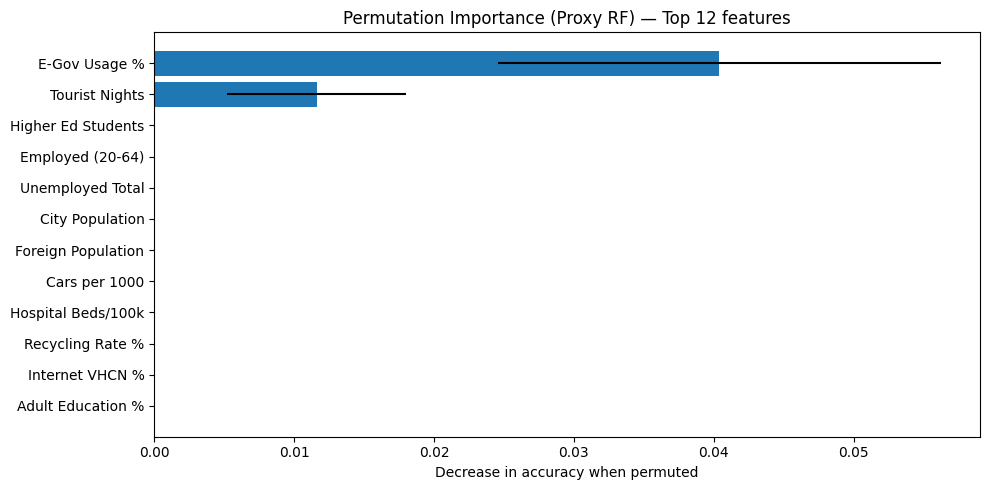

Saved: /Users/felixwegener/freelancing/data-analytics-project/output/clustering/custom_run_20260113_202817/feature_importance_perm_gmm.png


In [10]:
# --- 3) Supervised proxy: RandomForest + permutation importance ---
# Train a model to predict cluster_id from features, then see which features matter.
# This is NOT "ground truth" causality—just an interpretation aid.

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced_subsample",
)
rf.fit(X, y)
train_acc = rf.score(X, y)
print(f"Proxy model training accuracy (on same data): {train_acc:.3f}")

perm = permutation_importance(
    rf,
    X,
    y,
    n_repeats=30,
    random_state=42,
    scoring="accuracy",
)

fi_perm = (
    pd.DataFrame({
        "feature": X_scaled_df.columns,
        "feature_label": [clean_feature_name(c) for c in X_scaled_df.columns],
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(fi_perm.head(15))

# Plot top-N
top_n = 12
plot_df = fi_perm.head(top_n).iloc[::-1]
plt.figure(figsize=(10, 5))
plt.barh(plot_df["feature_label"], plot_df["importance_mean"], xerr=plot_df["importance_std"])
plt.title(f"Permutation Importance (Proxy RF) — Top {top_n} features")
plt.xlabel("Decrease in accuracy when permuted")
plt.tight_layout()
plt.savefig(RUN_DIR / f"feature_importance_perm_{ALGORITHM}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {RUN_DIR / f'feature_importance_perm_{ALGORITHM}.png'}")

## 6. What do the clusters tell us? (Summary)

This section turns the heatmap into an interpretable report:

- **Representative cities** per cluster
- **Top high/low drivers** per cluster (based on z-scores)
- A quick explanation of *why* singleton clusters (e.g., Paris/London) happen

In [11]:
def cluster_summary_table(
    heatmap_df: pd.DataFrame,
    labels_df: pd.DataFrame,
    *,
    z_thresh: float = 0.75,
    top_k: int = 5,
    n_city_examples: int = 8,
) -> pd.DataFrame:
    rows = []
    for cid in sorted(heatmap_df.index):
        row = heatmap_df.loc[cid]
        highs = row[row >= z_thresh].sort_values(ascending=False).head(top_k)
        lows = row[row <= -z_thresh].sort_values(ascending=True).head(top_k)

        cities = labels_df[labels_df["cluster_id"] == cid]["display_name"].tolist()
        rows.append(
            {
                "cluster_id": int(cid),
                "n_cities": int(len(cities)),
                "example_cities": ", ".join(cities[:n_city_examples]) + ("..." if len(cities) > n_city_examples else ""),
                "high_drivers": ", ".join([f"{k} (z={v:+.1f})" for k, v in highs.items()]) if len(highs) else "(none above threshold)",
                "low_drivers": ", ".join([f"{k} (z={v:+.1f})" for k, v in lows.items()]) if len(lows) else "(none below threshold)",
            }
        )
    return pd.DataFrame(rows).sort_values("cluster_id")

summary_df = cluster_summary_table(heatmap_df, labels_df, z_thresh=0.75, top_k=5)
display(summary_df)

# Heuristic: flag singleton clusters (these often dominate tuning constraints)
singletons = summary_df[summary_df["n_cities"] == 1]
if len(singletons):
    print("\nSingleton clusters detected (often caused by strong outliers):")
    display(singletons[["cluster_id", "example_cities", "high_drivers"]])

,cluster_id,n_cities,example_cities,high_drivers,low_drivers
0,0,43,"Bruxelles/Brussel (greater city), Antwerpen (g...",(none above threshold),(none below threshold)
1,1,6,"Berlin, Madrid (greater city), Barcelona (grea...","City Population (z=+2.7), Employed (20-64) (z=...",(none below threshold)
2,2,6,"Hamburg, München, Budapest (greater city), 's-...",Tourist Nights (z=+1.2),(none below threshold)
3,3,11,"Sofia, Zagreb, Torino, Palermo, Genova, Warsza...","Cars per 1000 (z=+1.5), PM2.5 (μg/m³) (z=+1.4)...","E-Gov Usage % (z=-1.4), Adult Education % (z=-..."


In [12]:
# Optional: explain one selected cluster in more detail
SELECT_CLUSTER = int(sorted(heatmap_df.index)[0])

row = heatmap_df.loc[SELECT_CLUSTER].sort_values(ascending=False)
highs = row.head(8)
lows = row.tail(8)

cities = labels_df[labels_df["cluster_id"] == SELECT_CLUSTER]["display_name"].tolist()

print(f"Cluster {SELECT_CLUSTER} — {len(cities)} cities")
print(f"Examples: {', '.join(cities[:12])}{'...' if len(cities) > 12 else ''}")
print("\nTop HIGH features:")
for k, v in highs.items():
    print(f"  + {k}: z={v:+.2f}")
print("\nTop LOW features:")
for k, v in lows.items():
    print(f"  - {k}: z={v:+.2f}")

Cluster 0 — 43 cities
Examples: Bruxelles/Brussel (greater city), Antwerpen (greater city), Zurich (greater city), Praha, Köln, Frankfurt am Main, Essen, Stuttgart, Leipzig, Dresden, Dortmund, Düsseldorf...

Top HIGH features:
  + E-Gov Usage %: z=+0.40
  + Adult Education %: z=+0.23
  + Recycling Rate %: z=+0.22
  + Hospital Beds/100k: z=+0.08
  + Internet VHCN %: z=+0.00
  + NO2 (μg/m³): z=-0.14
  + Employed (20-64): z=-0.25
  + Foreign Population: z=-0.27

Top LOW features:
  - Foreign Population: z=-0.27
  - Cars per 1000: z=-0.34
  - Higher Ed Students: z=-0.37
  - Unemployed Total: z=-0.39
  - Tourist Nights: z=-0.40
  - City Population: z=-0.40
  - PM2.5 (μg/m³): z=-0.40
  - PM10 (μg/m³): z=-0.44


## 5. Radar Charts

Radar charts visualize the **profile shape** of each cluster across key features. This makes it easy to compare clusters at a glance.

In [13]:
# Select top differentiating features for radar chart
# Use the most variable features across clusters
top_features = col_importance.head(8).index.tolist()

# Normalize z-scores to 0-1 range for radar chart
# Shift so minimum is 0, then scale to max of 1
radar_df = heatmap_df[top_features].copy()
for col in radar_df.columns:
    min_val = radar_df[col].min()
    max_val = radar_df[col].max()
    if max_val > min_val:
        radar_df[col] = (radar_df[col] - min_val) / (max_val - min_val)
    else:
        radar_df[col] = 0.5

print(f"Radar chart features (most differentiating): {top_features}")

Radar chart features (most differentiating): ['Employed (20-64)', 'City Population', 'Unemployed Total', 'Tourist Nights', 'Foreign Population', 'Higher Ed Students', 'Cars per 1000', 'E-Gov Usage %']


In [14]:
# Combined radar chart with all clusters
fig = go.Figure()

colors = px.colors.qualitative.Set1

for i, cluster_id in enumerate(sorted(radar_df.index)):
    values = radar_df.loc[cluster_id].tolist()
    # Close the radar by appending first value
    values += [values[0]]
    categories = top_features + [top_features[0]]
    
    n_cities = len(labels_df[labels_df["cluster_id"] == cluster_id])
    
    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=categories,
        fill="toself",
        name=f"Cluster {cluster_id} (n={n_cities})",
        line=dict(color=colors[i % len(colors)]),
        opacity=0.6
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1],
            tickvals=[0, 0.25, 0.5, 0.75, 1.0],
            ticktext=["Low", "", "Avg", "", "High"]
        )
    ),
    title="Cluster Profiles - Radar Chart Comparison",
    width=800,
    height=600,
    showlegend=True,
)

fig.show()
fig.write_html(RUN_DIR / f"radar_combined_{ALGORITHM}.html")
print(f"Saved radar chart to: {RUN_DIR / f'radar_combined_{ALGORITHM}.html'}")

Saved radar chart to: /Users/felixwegener/freelancing/data-analytics-project/output/clustering/custom_run_20260113_202817/radar_combined_gmm.html


In [15]:
# Print all generated files
print("=" * 70)
print("ALL OUTPUT FILES")
print("=" * 70)
for f in sorted(RUN_DIR.glob("*")):
    if f.is_file():
        print(f"  {f.name}")
    elif f.is_dir():
        print(f"  {f.name}/")
        for sub in sorted(f.glob("*")):
            print(f"    └── {sub.name}")

ALL OUTPUT FILES
  X_scaled.csv
  cluster_heatmap_gmm.png
  feature_importance_perm_gmm.png
  gmm/
    └── labels.csv
    └── model.pkl
    └── plot.png
    └── profiles.csv
  interactive_scatter_gmm.html
  kmeans/
    └── labels.csv
    └── model.pkl
    └── plot.png
    └── profiles.csv
  pca_loadings.png
  radar_combined_gmm.html
